<style>
    /* we can use injections to style the resulting pdf */

    /* wrapping */
    pre, .jp-CodeCell .jp-Editor {
        display: block!important;
    }
    .jp-Cell-inputArea pre {
           page-break-inside: avoid !important;
    }
    .cm-editor.cm-s-jupyter .highlight pre {
        white-space: pre-wrap !important;
    }

    /* margins */
    div#notebook-container,
    div.container,
    div#notebook,
    .jp-Notebook {
        max-width: none !important;
        width: 102.6% !important;
        margin-left: -2.6% !important;
        padding: 0 !important;
    }
    .jp-MarkdownCell {
        margin-left: -6px;
        margin-bottom: 8px;
        margin-top: 12px;
    }
    .jp-OutputArea .jp-RenderedText {
        padding-left: calc(1ch + 16px);
        padding-top: 4px;
        padding-bottom: 8px;
    }
</style>

In [1]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches
import nibabel as nib
from tqdm import tqdm
import ast

import albumentations as A
from albumentations.pytorch import ToTensorV2
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset

In [2]:
DATA_ROOT = 'data/MICCAI_BraTS2020_TrainingData'
OUTPUT_ROOT = 'processed_data_v3'

## 1. Bug fixes and pipeline optimizations
During the final phase of the project, we identified several logical and structural bugs in the data pipeline, model architecture, and evaluation metrics. This section provides a brief description of the changes made and includes the final code for the first milestone of the project.

#### Data preprocessing alignment fixes
##### 1. Background normalization strategy
* During normalization, the background is now strictly set to 0.0 (as opposed to the first version, where the background was set to -5.0).
* Considering that PyTorch’s Conv2d layers use zero-padding by default, matching the background to the padding value prevents the CNN from wasting parameters learning to ignore artificial borders. While average brain tissue might also normalize to 0.0, creating numerical overlap, CNNs extract features based on spatial textures rather than isolated pixel values. A uniform block of 0.0s is easily interpreted as background. This also aligns with state-of-the-art medical frameworks like nnU-Net.

##### 2. Global 3D patient cropping
* Initially, the center of mass for cropping was calculated on a per-slice basis, which destroyed the spatial relationship between slices, meaning they could no longer be accurately stacked back into a 3D volume for final patient-level evaluation.
* The crop bounding box is now computed once per patient in 3D during `process_and_index()`, using the T1 volume's brain mask across all spatial axes. These exact same `start_y` and `start_x` coordinates are now passed down and applied to every 2D slice belonging to that specific patient.

#### Loss function and evaluation
##### 1. Patient-level 3D dice metric
* The old `validate()` function computed the Dice score independently for each 2D slice and then averaged all slice-level scores. Since 57.3% of slices contain no tumor at all, these empty slices score 1.0 Dice, massively inflating the reported metric and masking poor segmentation on the slices that actually matter.
* The new `validate()` accumulates raw intersection and union statistics per-patient across all slices of that patient, then computes a single 3D volumetric Dice per patient at the end of the epoch. The final reported score is the mean of these per-patient 3D Dice values
* We also introduced an explicit handling of the empty masks - if a patient truly has no voxels of a given class, a true negative is silently skipped rather than scored 1.0, while a false positive is scored 0.0.
* Additionaly, the validation loop was rewritten to replace a `zip()` based approach with vectorized GPU tensor operations that compute batch intersections and unions simultaneously.

##### 2. Dice loss dimensionality
* Summing the Dice Loss over only the `dim=(2, 3)` caused gradient spikes when the model encountered batches containing empty background slices.
* New version aggregates across the entire batch before dividing (`dim=(0, 2, 3)`, which stabilizes the gradient signal and reduces the influence of individual empty slices.

#### Model architecture and training
##### 1. Training process
* We added flips and rotations via `Albumentations` to prevent rapid overfitting when training on only 10% of the data, replaced the static learning rate with a `ReduceLROnPlateau` scheduler to stabilize performance after early epochs, and increased the epoch number to 25.

##### 2. Dropout placement
* Dropout was originally placed only at the bottom bottleneck of the U-Net, which resulted in low-resolution uncertainty maps after upsampling.
In this version, we added `nn.Dropout2d(p=0.3)` layers in the decoder upsampling path (within the 128 and 64-channel blocks) to produce higher-resolution uncertainty maps.

In [3]:
# 2. DATA PREPARATION

In [4]:
os.makedirs(os.path.join(OUTPUT_ROOT, 'images'), exist_ok=True)
os.makedirs(os.path.join(OUTPUT_ROOT, 'masks'), exist_ok=True)

In [5]:
# 2.1. NORMALIZATION

In [6]:
def normalize(volume):
    volume = volume.copy()
    mask = volume > 0
    if not np.any(mask): return volume

    mean = volume[mask].mean()
    std = volume[mask].std()

    # we only normalize brain pixels
    volume[mask] = (volume[mask] - mean) / (std + 1e-8)
    # clip to remove extreme outliers
    volume[mask] = np.clip(volume[mask], -5, 5)

    volume[~mask] = 0.0

    return volume

In [7]:
# 2.2. EXTRACTION AND INDEXING

In [8]:
def process_and_index():
    patient_folders = [f for f in os.listdir(DATA_ROOT) if not f.endswith('.csv')]
    records = [] # to store CSV

    for patient in tqdm(patient_folders, desc="Processing"):
        path = os.path.join(DATA_ROOT, patient)

        # load data
        try:
            t1 = nib.load(os.path.join(path, f"{patient}_t1.nii")).get_fdata()
            t1ce = nib.load(os.path.join(path, f"{patient}_t1ce.nii")).get_fdata()
            t2 = nib.load(os.path.join(path, f"{patient}_t2.nii")).get_fdata()
            flair = nib.load(os.path.join(path, f"{patient}_flair.nii")).get_fdata()
            seg = nib.load(os.path.join(path, f"{patient}_seg.nii")).get_fdata()

        except Exception as e:
            print(f"Error loading {patient}: {e}")
            continue

        # calculate global 3D crop
        brain_mask_3d = t1 > 0
        if not np.any(brain_mask_3d):
            start_y, start_x = 24, 24
        else:
            y_indices, x_indices, _ = np.where(brain_mask_3d)
            center_y = (np.min(y_indices) + np.max(y_indices)) // 2
            center_x = (np.min(x_indices) + np.max(x_indices)) // 2

            start_y = max(0, center_y - 96)
            start_x = max(0, center_x - 96)

            if start_y + 192 > 240: start_y = 240 - 192
            if start_x + 192 > 240: start_x = 240 - 192

        # normalize
        t1 = normalize(t1)
        t1ce = normalize(t1ce)
        t2 = normalize(t2)
        flair = normalize(flair)

        # stack and map
        combined_img = np.stack([t1, t1ce, t2, flair], axis=-1).astype(np.float32)
        seg[seg == 4] = 3 # we map 4 to 3
        seg = seg.astype(np.uint8)

        # slice and save
        num_slices = combined_img.shape[2]
        for i in range(num_slices):
            # check if slice has tumor
            mask_slice = seg[:, :, i]
            has_tumor = 1 if np.max(mask_slice) > 0 else 0
            tumor_pixels = np.sum(mask_slice > 0)

            img_slice = combined_img[:, :, i, :]

            # e.g. BraTS_001_slice_055.npy
            slice_name = f"{patient}_slice_{i:03d}.npy"

            np.save(os.path.join(OUTPUT_ROOT, 'images', slice_name), img_slice)
            np.save(os.path.join(OUTPUT_ROOT, 'masks', slice_name), mask_slice)

            # add to index
            records.append({
                'filename': slice_name,
                'patient_id': patient,
                'slice_idx': i,
                'has_tumor': has_tumor,
                'tumor_pixels': tumor_pixels,
                'crop_start_y': start_y,
                'crop_start_x': start_x
            })

    df = pd.DataFrame(records)

    # split strategy
    unique_patients = df['patient_id'].unique()

    # hold out validation set (20%)
    train_pool_patients, val_patients = train_test_split(unique_patients, test_size=0.2, random_state=1)

    # split remaining into initial train (10%) and active loop pool (70%)
    pool_patients, initial_train_patients = train_test_split(train_pool_patients, test_size=0.125, random_state=1)

    df['subset'] = 'pool'
    df.loc[df['patient_id'].isin(initial_train_patients), 'subset'] = 'initial_train'
    df.loc[df['patient_id'].isin(val_patients), 'subset'] = 'val'

    # save CSV
    df.to_csv(os.path.join(OUTPUT_ROOT, 'data_splits.csv'), index=False)

    print(f"Total slices: {len(df)}")
    print(f"Initial train patients: {len(initial_train_patients)}")
    print(f"Active pool patients: {len(pool_patients)}")
    print(f"Validation patients: {len(val_patients)}")

In [ ]:
process_and_index()

In [9]:
# 3. DATASET LOADER CLASS

In [10]:
class BraTS25DDataset(Dataset):
    def __init__(self, csv_file, root_dir, patient_ids=None, transform=None, mode='train'):
        """
        Args:
            csv_file (string): Path to data_splits.csv.
            root_dir (string): Path to processed_data_v3.
            patient_ids (list): LIST of Patient IDs to include.
                                If None, it uses all patients in the CSV.
            transform (callable, optional): Albumentations transforms.
            mode (string): 'train', 'val', or 'test'.
                           - 'train' returns (image, mask).
                           - 'val' returns (image, mask).
                           - 'test' returns (image, filename) for inference.
        """
        self.root_dir = root_dir
        self.transform = transform
        self.mode = mode

        # 1. load the index
        df = pd.read_csv(csv_file)

        # 2. filter by specific patient list (the active learning logic)
        if patient_ids is not None:
            self.df = df[df['patient_id'].isin(patient_ids)].copy()
        else:
            self.df = df.copy()

        # 3. create a quick lookup for slice existence
        self.valid_slices = set(zip(self.df['patient_id'], self.df['slice_idx']))

        self.records = self.df.to_dict('records')

    def __len__(self):
        return len(self.records)

    def _load_slice(self, patient_id, slice_idx):
        if (patient_id, slice_idx) not in self.valid_slices:
            return None

        filename = f"{patient_id}_slice_{slice_idx:03d}.npy"
        path = os.path.join(self.root_dir, 'images', filename)

        # shape: (240, 240, 4)
        return np.load(path).astype(np.float32)

    def __getitem__(self, idx):
        row = self.records[idx]
        patient_id = row['patient_id']
        current_idx = row['slice_idx']

        start_y = row['crop_start_y']
        start_x = row['crop_start_x']
        crop_size = 192

        # 1. load 2.5D stack (prev, curr, next)
        prev_slice = self._load_slice(patient_id, current_idx - 1)
        curr_slice = self._load_slice(patient_id, current_idx)
        next_slice = self._load_slice(patient_id, current_idx + 1)

        # handle edge cases
        if prev_slice is None: prev_slice = curr_slice
        if next_slice is None: next_slice = curr_slice

        # stack channels: (240, 240, 12)
        image = np.concatenate([prev_slice, curr_slice, next_slice], axis=-1)

        # 2. load mask
        mask = None
        if self.mode != 'test':
            mask_filename = row['filename']
            mask_path = os.path.join(self.root_dir, 'masks', mask_filename)
            mask = np.load(mask_path).astype(np.float32) # (240, 240)

        # 3. smart crop
        image = image[start_y:start_y+crop_size, start_x:start_x+crop_size, :]
        if mask is not None:
            mask = mask[start_y:start_y+crop_size, start_x:start_x+crop_size]

        # apply albumentations
        if self.transform:
            if mask is not None:
                mask = np.expand_dims(mask, axis=-1) # (192, 192, 1) for Albumentations
                augmented = self.transform(image=image, mask=mask)
                image = augmented['image']
                mask = augmented['mask']
            else:
                augmented = self.transform(image=image)
                image = augmented['image']
        else:
            # manual conversion if no transform is provided
            image = torch.from_numpy(image).permute(2, 0, 1) # (12, 192, 192)
            if mask is not None:
                mask = torch.from_numpy(mask).long()

        # 5. final formatting
        image = image.float()
        if mask is not None:
            # to ensure mask is (192, 192) long tensor
            if len(mask.shape) == 3:
                mask = mask.squeeze(0)
            return image, mask.long(), patient_id

        return image, row['filename'], patient_id

In [11]:
# 4. U-NET IMPLEMENTATION

In [12]:
class DoubleConv(nn.Module):
    """(Conv2d => BN => ReLU) * 2"""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.double_conv(x)

In [13]:
class AgileUNet(nn.Module):
    def __init__(self, n_channels=12, n_classes=4): # 12 channels input
        super(AgileUNet, self).__init__()

        # ENCODER
        # we start with 32 filters to save memory
        # structure: 32 -> 64 -> 128 -> 256 (Bottom)

        self.inc = DoubleConv(n_channels, 32)
        self.down1 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(32, 64))
        self.down2 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(64, 128))

        # THE BRIDGE
        self.down3 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(128, 256))
        self.dropout = nn.Dropout2d(p=0.3) # dropout

        # DECODER
        # we use UpSampling (Bilinear) instead of ConvTranspose2d to save parameters

        self.up1 = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.conv_up1 = DoubleConv(256 + 128, 128) # in = 256(up) + 128(skip)
        self.dropout_up1 = nn.Dropout2d(p=0.3) # dropout

        self.up2 = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.conv_up2 = DoubleConv(128 + 64, 64)
        self.dropout_up2 = nn.Dropout2d(p=0.3) # dropout

        self.up3 = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.conv_up3 = DoubleConv(64 + 32, 32)

        self.outc = nn.Conv2d(32, n_classes, kernel_size=1)

    def forward(self, x):
        # encoder
        x1 = self.inc(x)       # [B, 32, H, W]
        x2 = self.down1(x1)    # [B, 64, H/2, W/2]
        x3 = self.down2(x2)    # [B, 128, H/4, W/4]
        x4 = self.down3(x3)    # [B, 256, H/8, W/8]

        x4 = self.dropout(x4)

        # decoder
        x = self.up1(x4)
        # auto-padding to handle rounding errors if H/W aren't perfect powers of 2
        if x.shape != x3.shape:
            x = F.interpolate(x, size=x3.shape[2:], mode='bilinear', align_corners=True)
        x = torch.cat([x, x3], dim=1)
        x = self.conv_up1(x)
        x = self.dropout_up1(x)

        x = self.up2(x)
        if x.shape != x2.shape:
            x = F.interpolate(x, size=x2.shape[2:], mode='bilinear', align_corners=True)
        x = torch.cat([x, x2], dim=1)
        x = self.conv_up2(x)
        x = self.dropout_up2(x)

        x = self.up3(x)
        if x.shape != x1.shape:
            x = F.interpolate(x, size=x1.shape[2:], mode='bilinear', align_corners=True)
        x = torch.cat([x, x1], dim=1)
        x = self.conv_up3(x)

        logits = self.outc(x)
        return logits

In [14]:
class DiceLoss(nn.Module):
    def __init__(self, n_classes=4, smooth=1e-6):
        super(DiceLoss, self).__init__()
        self.n_classes = n_classes
        self.smooth = smooth

    def forward(self, inputs, targets):
        # inputs: [B, 4, H, W]
        # targets: [B, H, W] OR [B, H, W, 1] (the bug source)

        # 1. softmax to get probabilities
        inputs = F.softmax(inputs, dim=1)

        # 2. fix targets shape
        # if targets has an extra channel dim [B, H, W, 1], squeeze it to [B, H, W]
        if targets.dim() == 4 and targets.shape[-1] == 1:
            targets = targets.squeeze(-1)
        # or if it came in as [B, 1, H, W]
        if targets.dim() == 4 and targets.shape[1] == 1:
            targets = targets.squeeze(1)

        # 3. one-hot encoding (CPU workaround for DirectML)
        targets_cpu = targets.cpu().long()
        targets_one_hot = F.one_hot(targets_cpu, num_classes=self.n_classes) # result: [B, H, W, C]

        # 4. permute to match Inputs [B, C, H, W]
        # [B, H, W, C] -> [B, C, H, W]
        targets_one_hot = targets_one_hot.permute(0, 3, 1, 2).float().to(inputs.device)

        # 5. calculate dice
        # sum over batch (0) AND spatial dimensions (2, 3)
        intersection = (inputs * targets_one_hot).sum(dim=(0, 2, 3))
        union = inputs.sum(dim=(0, 2, 3)) + targets_one_hot.sum(dim=(0, 2, 3))

        dice = (2. * intersection + self.smooth) / (union + self.smooth)

        # 6. average dice
        return 1 - dice[1:].mean()

In [15]:
# 5. BABY MODEL TRAINING

In [16]:
# 5.1. CONFIG

import torch_directml
DEVICE = torch_directml.device()
print(DEVICE)

privateuseone:0


In [17]:
BATCH_SIZE = 16  # increased since we use AgileUNet + 160x160
LR = 3e-4        # AdamW standard
EPOCHS = 25      # for the initial training

In [18]:
train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    ToTensorV2()
])

val_transform = A.Compose([
    ToTensorV2()
])

In [19]:
# 5.3. TRAIN STEP
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    loop = tqdm(loader, desc="Training", leave=False)

    for images, masks, _ in loop:
        images = images.to(device).float()
        masks = masks.to(device).long()

        # forward
        outputs = model(images)
        loss = criterion(outputs, masks)

        # backward
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        loop.set_postfix(loss=loss.item())

    return running_loss / len(loader)

In [20]:
# 5.4. VALIDATION STEP
def validate(model, loader, criterion, device):
    model.eval()
    val_loss = 0.0

    patient_stats = {}

    with torch.no_grad():
        loop = tqdm(loader, desc="Validation", leave=False)

        for images, masks, patient_ids in loop:
            images = images.to(device).float()
            masks = masks.to(device).long()

            outputs = model(images)
            loss = criterion(outputs, masks)
            val_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)

            # squeeze extra dimension if present [B, H, W, 1] -> [B, H, W]
            if masks.dim() == 4 and masks.shape[-1] == 1:
                masks = masks.squeeze(-1)

            B = images.shape[0]
            for class_idx in [1, 2, 3]:
                pred_c = (preds == class_idx)
                mask_c = (masks == class_idx)

                # we flatten spatial dimensions and sum on GPU
                int_batch = (pred_c & mask_c).view(B, -1).sum(dim=1).cpu().numpy()
                un_batch = (pred_c.view(B, -1).sum(dim=1) + mask_c.view(B, -1).sum(dim=1)).cpu().numpy()
                gt_batch = mask_c.view(B, -1).sum(dim=1).cpu().numpy()

                # and assign to python dictionary
                for i, patient_id in enumerate(patient_ids):
                    if patient_id not in patient_stats:
                        patient_stats[patient_id] = {
                            1: {'int': 0.0, 'un': 0.0, 'gt_vol': 0.0},
                            2: {'int': 0.0, 'un': 0.0, 'gt_vol': 0.0},
                            3: {'int': 0.0, 'un': 0.0, 'gt_vol': 0.0}
                        }
                    patient_stats[patient_id][class_idx]['int'] += int_batch[i]
                    patient_stats[patient_id][class_idx]['un'] += un_batch[i]
                    patient_stats[patient_id][class_idx]['gt_vol'] += gt_batch[i]

    avg_loss = val_loss / len(loader)

    # calculate 3D Dice per patient
    class_dice_scores = {1: [], 2: [], 3: []}

    for pid, stats in patient_stats.items():
        for class_idx in [1, 2, 3]:
            intersection = stats[class_idx]['int']
            union = stats[class_idx]['un']
            gt_vol = stats[class_idx].get('gt_vol', 0)

            if gt_vol == 0:
                if union == 0:
                    # model correctly predicted nothing, do not append anything
                    continue
                else:
                    # model hallucinated a tumor, heavily penalize with a 0.0
                    class_dice_scores[class_idx].append(0.0)
            else:
                dice = (2. * intersection) / (union + 1e-6)
                class_dice_scores[class_idx].append(dice)

    # average the patient scores
    avg_dice = {}
    for c, scores in class_dice_scores.items():
        avg_dice[c] = np.mean(scores) if len(scores) > 0 else 1.0

    return avg_loss, avg_dice

In [21]:
# we use the 'initial_train' subset we defined in the splits CSV
df = pd.read_csv('processed_data_v3/data_splits.csv')
initial_patients = df[df['subset'] == 'initial_train']['patient_id'].unique().tolist()
val_patients = df[df['subset'] == 'val']['patient_id'].unique().tolist()

In [22]:
# 5.5. MAIN LOOP

def run_training():
    print(f"Device: {DEVICE}")

    train_ds = BraTS25DDataset(
        csv_file='processed_data_v3/data_splits.csv',
        root_dir='processed_data_v3',
        patient_ids=initial_patients,
        transform=train_transform,
        mode='train'
    )

    val_ds = BraTS25DDataset(
        csv_file='processed_data_v3/data_splits.csv',
        root_dir='processed_data_v3',
        patient_ids=val_patients,
        transform=val_transform,
        mode='train'
    )

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

    print(f"Training on {len(train_ds)} slices | Validating on {len(val_ds)} slices")

    # model setup
    model = AgileUNet(n_channels=12, n_classes=4).to(DEVICE)
    optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
    criterion = DiceLoss(n_classes=4)

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.5, patience=3
    )

    # epoch loop
    best_score = 0.0

    for epoch in range(EPOCHS):
        print(f"\nEpoch {epoch+1}/{EPOCHS}")

        train_loss = train_one_epoch(model, train_loader, optimizer, criterion, DEVICE)
        val_loss, val_dice = validate(model, val_loader, criterion, DEVICE)

        # mean dice (WT + TC + ET) / 3
        mean_dice = np.mean(list(val_dice.values()))

        print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
        print(f"Dice - NCR: {val_dice[1]:.3f}, ED: {val_dice[2]:.3f}, ET: {val_dice[3]:.3f} | Mean: {mean_dice:.3f}")

        scheduler.step(mean_dice)

        # save checkpoint
        if mean_dice > best_score:
            best_score = mean_dice
            torch.save(model.state_dict(), "artifacts/best_model_initial.pth")
            print("Saved best model")

In [ ]:
run_training()

## 6. The active learning loop

After fixing the bugs, regenerating the data, and training the new baby model, we moved on to the final phase of the project - implementing and executing the active learning loop. The key design decisions and architectural features of this implementation are described below:

#### Overall structure

* The experiment consists of three active learning iterations, each adding 10 patients to the training set. Initially, the setup includes 37 patients in the fixed seed training set (baby model), 74 patients in a fixed validation set, and 258 patients in the unlabeled AL pool. In each iteration, the current AL model (the baby model during loop 0) evaluates all patients in the AL pool, assigns an uncertainty score, and selects the top 10 most uncertain cases. These are added to the training set, and a new model is retrained from scratch.
* To evaluate whether intelligent selection actually outperforms chance, a random baseline runs in parallel. To ensure the Random Baseline is a mathematically fair competitor, the AL model and Random model draw from two separate, identical pools. With the Random Baseline method, there is no need to select patients based on an uncertainty score - its 30 patients were generated upfront with a fixed seed to guarantee reproducibility.
* All six models trained during the experiment are initialized with random weights and trained for a fixed 25 epochs on their respective labeled sets.

#### Uncertainty estimation

* In the first version of the code, uncertainty was calculated using `epistemic_uncertainty = variance.mean(axis=1)` (we were averaging the variance across all 4 classes, which artificially lowered the uncertainty score).
* This motivated us switching to BALD, which computes predictive entropy minus expected entropy across all MC Dropout passes. This  isolates epistemic uncertainty (reflecting the model’s lack of knowledge about this anatomical structure) from aleatoric uncertainty (inherent noise/blur in the MRI) - which is what active learning aims to target

#### Patient Scoring
* Converting 2.5D slice-level uncertainty into a single patient-level score is challenging. We considered Mean-Averaging all slices (which dilutes scores with empty skull slices) and Probability Thresholds (which hides rare tumors the model fails to predict).
* The chosen approach reconstructs the patient's full 3D variance map, applies a brain mask (derived directly from the raw MRI), and takes the mean of the Top 5% highest BALD voxels across the entire brain.

In [23]:
# 6.1. SETUP

In [24]:
CSV_PATH  = 'processed_data_v3/data_splits.csv'

In [25]:
MC_SAMPLES = 10   # passes for BALD
TOP_K_PCT = 0.05  # top 5% of brain voxels for patient score aggregation
AL_BATCH  = 64    # batch size for pool scanning
EPOCHS    = 25

In [26]:
df = pd.read_csv(CSV_PATH)

initial_patients = df[df['subset'] == 'initial_train']['patient_id'].unique().tolist()
val_patients_list = df[df['subset'] == 'val']['patient_id'].unique().tolist()
pool_patients     = df[df['subset'] == 'pool']['patient_id'].unique().tolist()

In [27]:
print(f"Initial train patients: {len(initial_patients)}")
print(f"Validation patients: {len(val_patients_list)}")
print(f"Unlabeled pool patients: {len(pool_patients)}")

Initial train patients: 37
Validation patients: 74
Unlabeled pool patients: 258


In [28]:
# we draw all 30 patients upfront with a fixed seed
rng = np.random.RandomState(1)
all_random_selections = rng.choice(pool_patients, size=30, replace=False).tolist()

random_selections_per_loop = {
    1: all_random_selections[0:10],
    2: all_random_selections[10:20],
    3: all_random_selections[20:30],
}

In [29]:
print("Random Baseline patients:")
for loop_num, pats in random_selections_per_loop.items():
    print(f"Loop {loop_num}: {pats}")

Random Baseline patients:
Loop 1: ['BraTS20_Training_260', 'BraTS20_Training_047', 'BraTS20_Training_265', 'BraTS20_Training_328', 'BraTS20_Training_308', 'BraTS20_Training_256', 'BraTS20_Training_228', 'BraTS20_Training_036', 'BraTS20_Training_207', 'BraTS20_Training_267']
Loop 2: ['BraTS20_Training_369', 'BraTS20_Training_088', 'BraTS20_Training_008', 'BraTS20_Training_325', 'BraTS20_Training_060', 'BraTS20_Training_233', 'BraTS20_Training_362', 'BraTS20_Training_072', 'BraTS20_Training_217', 'BraTS20_Training_333']
Loop 3: ['BraTS20_Training_101', 'BraTS20_Training_139', 'BraTS20_Training_269', 'BraTS20_Training_316', 'BraTS20_Training_326', 'BraTS20_Training_120', 'BraTS20_Training_053', 'BraTS20_Training_337', 'BraTS20_Training_188', 'BraTS20_Training_292']


In [30]:
def enable_dropout(m):
    if type(m) == torch.nn.Dropout2d:
        m.train()

In [31]:
# 6.2. BALD SCORING UTILITIES

In [32]:
def score_patient_bald(model, patient_id, device,
                       csv_path=CSV_PATH, root_dir=OUTPUT_ROOT,
                       mc_samples=MC_SAMPLES, batch_size=AL_BATCH,
                       top_k_pct=TOP_K_PCT):

    model.eval()
    model.apply(enable_dropout)

    patient_ds = BraTS25DDataset(
        csv_file=csv_path, root_dir=root_dir, patient_ids=[patient_id],
        transform=val_transform, mode='test'
    )

    patient_loader = DataLoader(
        patient_ds, batch_size=batch_size, shuffle=False, num_workers=0
    )

    all_bald_brain_values =[]
    eps = 1e-8

    with torch.no_grad():
        for images, _filenames, _pids in patient_loader:
            images = images.to(device).float()
            B = images.shape[0]

            # accumulators on the CPU
            sum_probs = torch.zeros((B, 4, 192, 192))
            sum_entropy = torch.zeros((B, 192, 192))

            for _ in range(mc_samples):
                # forward pass on GPU
                logits = model(images)
                probs  = F.softmax(logits, dim=1)

                # entropy math on GPU
                pass_entropy = -(probs * torch.log(probs + eps)).sum(dim=1)

                # to avoid RAM overflow
                sum_probs += probs.cpu()
                sum_entropy += pass_entropy.cpu()

            mean_probs = sum_probs / mc_samples
            mean_entropy = sum_entropy / mc_samples

            pred_entropy = -(mean_probs * torch.log(mean_probs + eps)).sum(dim=1)
            bald_map = (pred_entropy - mean_entropy).clamp(min=0.0)

            brain_mask = (images[:, 4:8, :, :].abs() > 1e-6).any(dim=1).cpu()

            for b in range(B):
                masked_values = bald_map[b][brain_mask[b]]
                if len(masked_values) > 0:
                    all_bald_brain_values.append(masked_values.numpy())

    if not all_bald_brain_values:
        return 0.0

    all_values = np.concatenate(all_bald_brain_values)
    k = max(1, int(len(all_values) * top_k_pct))
    top_k_values = np.partition(all_values, -k)[-k:]

    return float(top_k_values.mean())

In [33]:
# 6.3. POOL SCANNING

In [34]:
def scan_pool(model, patient_ids, device,
              loop_idx=None, mc_samples=MC_SAMPLES):

    scores = {}
    print(f"\n  Scoring {len(patient_ids)} pool patients ({mc_samples} MC passes each)")

    for patient_id in tqdm(patient_ids, desc="  Scanning pool"):
        scores[patient_id] = score_patient_bald(
            model, patient_id, device, mc_samples=mc_samples
        )

    sorted_scores = dict(
        sorted(scores.items(), key=lambda x: x[1], reverse=True)
    )

    if loop_idx is not None:
        save_path = f'al_scores_loop_{loop_idx}.csv'
        pd.DataFrame({
            'patient_id': list(sorted_scores.keys()),
            'bald_score': list(sorted_scores.values())
        }).to_csv(save_path, index=False)
        print(f"  Saved uncertainty scores: {save_path}")

    return sorted_scores

In [35]:
# 6.4. TRAINING WRAPPER

In [36]:
def train_model_from_scratch(patient_ids, checkpoint_name,
                              device=DEVICE, epochs=EPOCHS):

    train_ds = BraTS25DDataset(
        csv_file=CSV_PATH,
        root_dir=OUTPUT_ROOT,
        patient_ids=patient_ids,
        transform=train_transform,
        mode='train'
    )
    val_ds = BraTS25DDataset(
        csv_file=CSV_PATH,
        root_dir=OUTPUT_ROOT,
        patient_ids=val_patients_list,
        transform=val_transform,
        mode='train'
    )

    train_loader = DataLoader(
        train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0
    )
    val_loader = DataLoader(
        val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0
    )

    print(f"\n  Training on {len(train_ds)} slices "
          f"({len(patient_ids)} patients) | "
          f"Validating on {len(val_ds)} slices")

    # random initialization
    model = AgileUNet(n_channels=12, n_classes=4).to(device)
    optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
    criterion = DiceLoss(n_classes=4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.5, patience=3
    )

    best_score = 0.0
    best_dice  = {}

    for epoch in range(epochs):
        print(f"\nEpoch {epoch+1}/{epochs}", end='  ')
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val_loss, val_dice = validate(model, val_loader, criterion, device)
        mean_dice = np.mean(list(val_dice.values()))

        print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
              f"Dice NCR: {val_dice[1]:.3f}  ED: {val_dice[2]:.3f}  "
              f"ET: {val_dice[3]:.3f}  Mean: {mean_dice:.3f}")

        scheduler.step(mean_dice)

        if mean_dice > best_score:
            best_score = mean_dice
            best_dice  = val_dice.copy()
            torch.save(model.state_dict(), checkpoint_name)
            print(f"  Saved best checkpoint: {checkpoint_name}")

    return best_score, best_dice

In [ ]:
# 6.5. BABY MODEL BASELINE (loop 0)

In [ ]:
baby_model = AgileUNet(n_channels=12, n_classes=4).to(DEVICE)
baby_model.load_state_dict(
    torch.load('artifacts/best_model_initial.pth', map_location=DEVICE)
)

_val_ds_baseline = BraTS25DDataset(
    csv_file=CSV_PATH, root_dir=OUTPUT_ROOT,
    patient_ids=val_patients_list, transform=val_transform, mode='train'
)
_val_loader_baseline = DataLoader(
    _val_ds_baseline, batch_size=BATCH_SIZE, shuffle=False, num_workers=0
)
_criterion_baseline = DiceLoss(n_classes=4)

_, baby_dice = validate(baby_model, _val_loader_baseline, _criterion_baseline, DEVICE)
baby_mean = float(np.mean(list(baby_dice.values())))

print(f"Baby Model — NCR: {baby_dice[1]:.3f}  ED: {baby_dice[2]:.3f}  "
      f"ET: {baby_dice[3]:.3f}  Mean: {baby_mean:.3f}")

In [ ]:
results_log = [{
    'loop':            0,
    'n_labeled':       len(initial_patients),
    'al_mean_dice':    baby_mean,
    'al_ncr':          baby_dice[1],
    'al_ed':           baby_dice[2],
    'al_et':           baby_dice[3],
    'random_mean_dice': baby_mean,
    'random_ncr':      baby_dice[1],
    'random_ed':       baby_dice[2],
    'random_et':       baby_dice[3],
    'al_patients_added':     [],
    'random_patients_added': [],
}]

In [ ]:
# 6.6. THE ACTIVE LEARNING LOOP

In [ ]:
al_selected = []
random_selected = []

al_pool = list(pool_patients)
random_pool = list(pool_patients)

In [ ]:
# the scanning model for Loop 1 is the Baby Model,
# after each loop it is replaced with the newly trained AL model
current_scan_model = baby_model

In [ ]:
for loop_idx in range(1, 4):
    print(f"\nACTIVE LEARNING LOOP {loop_idx} / 3")

    # 1. scan the AL pool with the current model
    scores = scan_pool(
        model=current_scan_model,
        patient_ids=al_pool,
        device=DEVICE,
        loop_idx=loop_idx,
        mc_samples=MC_SAMPLES
    )

    # 2. select patients
    new_al_patients = list(scores.keys())[:10]
    al_selected.extend(new_al_patients)
    al_pool = [p for p in al_pool if p not in new_al_patients]

    new_random_patients = random_selections_per_loop[loop_idx]
    random_selected.extend(new_random_patients)
    random_pool = [p for p in random_pool if p not in new_random_patients]

    print(f"\nAL selected  ({len(al_selected)} total): {new_al_patients}")
    print(f"Rand selected({len(random_selected)} total): {new_random_patients}")

    # 3. train AL model from scratch
    al_train_ids = initial_patients + al_selected
    print(f"\n  [AL_Model_v{loop_idx}] Training on {len(al_train_ids)} patients...")

    al_score, al_dice = train_model_from_scratch(
        patient_ids=al_train_ids,
        checkpoint_name=f'al_model_v{loop_idx}.pth',
    )

    # 4. train random model from scratch
    rand_train_ids = initial_patients + random_selected
    print(f"\n  [Random_Model_v{loop_idx}] Training on {len(rand_train_ids)} patients...")

    rand_score, rand_dice = train_model_from_scratch(
        patient_ids=rand_train_ids,
        checkpoint_name=f'random_model_v{loop_idx}.pth',
    )

    # 5. log results
    results_log.append({
        'loop':              loop_idx,
        'n_labeled':         len(al_train_ids),
        'al_mean_dice':      al_score,
        'al_ncr':            al_dice[1],
        'al_ed':             al_dice[2],
        'al_et':             al_dice[3],
        'random_mean_dice':  rand_score,
        'random_ncr':        rand_dice[1],
        'random_ed':         rand_dice[2],
        'random_et':         rand_dice[3],
        'al_patients_added':     new_al_patients,
        'random_patients_added': new_random_patients,
    })

    results_df = pd.DataFrame(results_log)
    results_df.to_csv('docs/al_results.csv', index=False)

    print(f"\n── Loop {loop_idx} Summary ──────────────────────────")
    print(f"  AL     Mean Dice: {al_score:.4f}  "
          f"(NCR {al_dice[1]:.3f}  ED {al_dice[2]:.3f}  ET {al_dice[3]:.3f})")
    print(f"  Random Mean Dice: {rand_score:.4f}  "
          f"(NCR {rand_dice[1]:.3f}  ED {rand_dice[2]:.3f}  ET {rand_dice[3]:.3f})")
    print(f"  Saved al_results.csv")

    # 6. load the new AL model as the scanner for the next loop
    current_scan_model = AgileUNet(n_channels=12, n_classes=4).to(DEVICE)
    current_scan_model.load_state_dict(
        torch.load(f'al_model_v{loop_idx}.pth', map_location=DEVICE)
    )

In [37]:
# 7. VISUALIZATIONS

In [38]:
results_df = pd.read_csv('docs/al_results.csv')

In [39]:
n_patients = results_df['n_labeled'].tolist()
al_curve = results_df['al_mean_dice'].tolist()
rand_curve = results_df['random_mean_dice'].tolist()

In [40]:
summary = results_df[['loop', 'n_labeled', 'al_mean_dice', 'random_mean_dice']].copy()
summary['delta'] = summary['al_mean_dice'] - summary['random_mean_dice']
summary.columns = ['Loop', 'Patients', 'AL Dice', 'Random Dice', 'Δ (AL − Rand)']
print(summary.to_string(index=False, float_format='{:.4f}'.format))

 Loop  Patients  AL Dice  Random Dice  Δ (AL − Rand)
    0        37   0.6740       0.6740         0.0000
    1        47   0.6664       0.6733        -0.0069
    2        57   0.6814       0.6743         0.0071
    3        67   0.6907       0.6839         0.0068


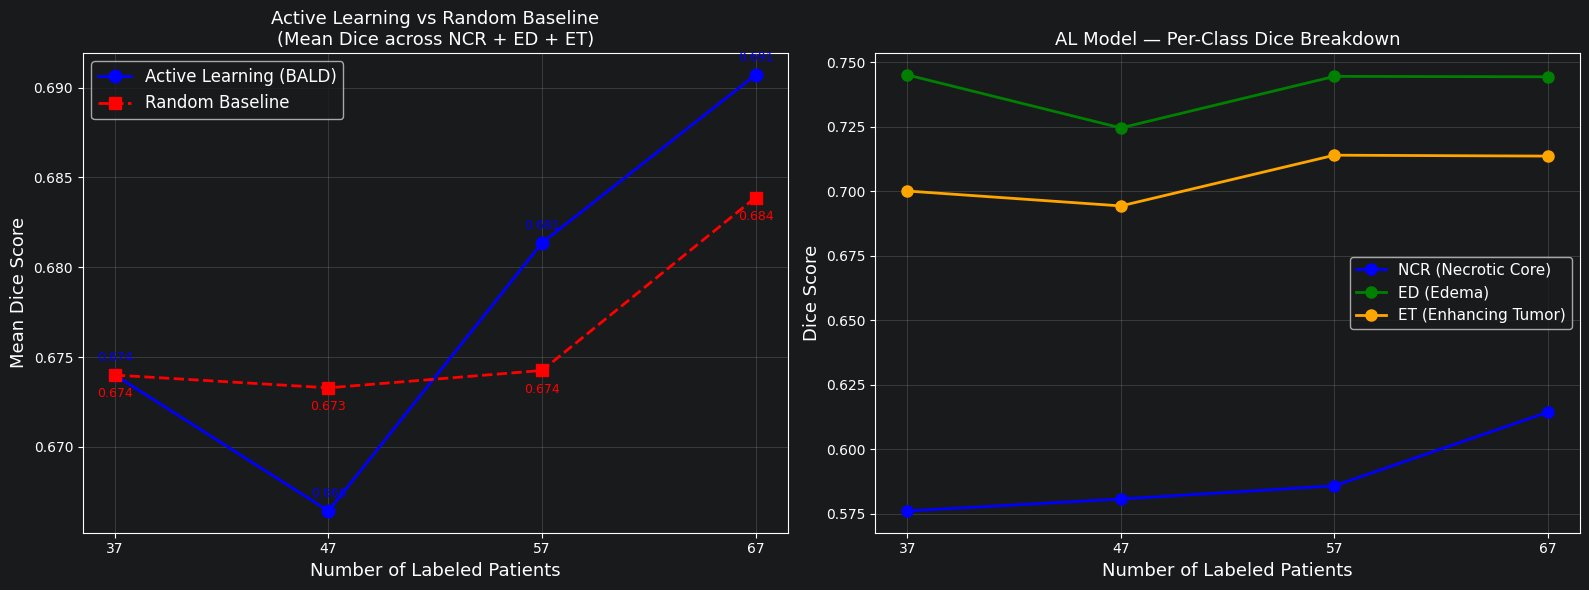

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# overall mean dice
ax = axes[0]
ax.plot(n_patients, al_curve,   'b-o', linewidth=2, markersize=9,label='Active Learning (BALD)')
ax.plot(n_patients, rand_curve, 'r--s', linewidth=2, markersize=9, label='Random Baseline')
ax.set_xlabel('Number of Labeled Patients', fontsize=13)
ax.set_ylabel('Mean Dice Score', fontsize=13)
ax.set_title('Active Learning vs Random Baseline\n(Mean Dice across NCR + ED + ET)', fontsize=13)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
ax.set_xticks(n_patients)

for x, y_al, y_r in zip(n_patients, al_curve, rand_curve):
    ax.annotate(f'{y_al:.3f}', (x, y_al), textcoords="offset points",
                xytext=(0, 10), ha='center', fontsize=9, color='blue')
    ax.annotate(f'{y_r:.3f}', (x, y_r), textcoords="offset points",
                xytext=(0, -16), ha='center', fontsize=9, color='red')

# per-class dice
ax2 = axes[1]
class_labels = {
    'al_ncr': ('NCR (Necrotic Core)', 'blue'),
    'al_ed':  ('ED (Edema)', 'green'),
    'al_et':  ('ET (Enhancing Tumor)','orange'),
}
for col, (label, color) in class_labels.items():
    ax2.plot(n_patients, results_df[col].tolist(),
             '-o', linewidth=2, markersize=8, label=label, color=color)

ax2.set_xlabel('Number of Labeled Patients', fontsize=13)
ax2.set_ylabel('Dice Score', fontsize=13)
ax2.set_title('AL Model — Per-Class Dice Breakdown', fontsize=13)
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)
ax2.set_xticks(n_patients)

plt.tight_layout()
plt.show()

In [42]:
results_df['al_patients_added'] = results_df['al_patients_added'].apply(ast.literal_eval)
results_df['random_patients_added'] = results_df['random_patients_added'].apply(ast.literal_eval)

In [43]:
# custom colormap (0: transparent, 1: Red (NCR), 2: Green (ED), 3: Yellow (ET))
cmap_mask = ListedColormap(['none', 'red', 'green', 'yellow'])

In [44]:
# loop 3 selections gallery
def plot_selection_gallery(loop_idx=3):

    al_pids = results_df[results_df['loop'] == loop_idx]['al_patients_added'].values[0]
    rand_pids = results_df[results_df['loop'] == loop_idx]['random_patients_added'].values[0]

    def get_max_tumor_slice(patient_id):
        # we find the slice with the maximum number of tumor pixels
        p_df = df[(df['patient_id'] == patient_id) & (df['has_tumor'] == 1)]
        if len(p_df) == 0: return None
        best_row = p_df.loc[p_df['tumor_pixels'].idxmax()]
        return best_row

    fig, axes = plt.subplots(4, 5, figsize=(20, 16))
    fig.suptitle(f'Loop {loop_idx} Selections: Active Learning vs. Random Baseline\n(T1ce MRI with Ground Truth Mask Overlay)',
                 fontsize=20, y=0.95)

    # AL patients
    for i, pid in enumerate(al_pids):
        ax = axes[i // 5, i % 5]
        row = get_max_tumor_slice(pid)
        if row is not None:
            img = np.load(os.path.join(OUTPUT_ROOT, 'images', row['filename']))
            mask = np.load(os.path.join(OUTPUT_ROOT, 'masks', row['filename']))

            sy, sx = row['crop_start_y'], row['crop_start_x']
            img_crop = img[sy:sy+192, sx:sx+192, 1]
            mask_crop = mask[sy:sy+192, sx:sx+192]

            ax.imshow(img_crop, cmap='gray')
            ax.imshow(mask_crop, cmap=cmap_mask, alpha=0.4, interpolation='nearest')
            ax.set_title(f"AL: {pid}\nMax Area: {row['tumor_pixels']} px", fontsize=10)
        ax.axis('off')

    # random patients
    for i, pid in enumerate(rand_pids):
        ax = axes[(i // 5) + 2, i % 5]
        row = get_max_tumor_slice(pid)
        if row is not None:
            img = np.load(os.path.join(OUTPUT_ROOT, 'images', row['filename']))
            mask = np.load(os.path.join(OUTPUT_ROOT, 'masks', row['filename']))

            sy, sx = row['crop_start_y'], row['crop_start_x']
            img_crop = img[sy:sy+192, sx:sx+192, 1]
            mask_crop = mask[sy:sy+192, sx:sx+192]

            ax.imshow(img_crop, cmap='gray')
            ax.imshow(mask_crop, cmap=cmap_mask, alpha=0.4, interpolation='nearest')
            ax.set_title(f"Rand: {pid}\nMax Area: {row['tumor_pixels']} px", fontsize=10)
        ax.axis('off')

    fig.text(0.08, 0.75, 'Active\nLearning\nSelections', va='center', ha='center', fontsize=16, fontweight='bold', rotation=90)
    fig.text(0.08, 0.30, 'Random\nBaseline\nSelections', va='center', ha='center', fontsize=16, fontweight='bold', rotation=90)

    plt.subplots_adjust(wspace=0.1, hspace=0.2)
    plt.show()

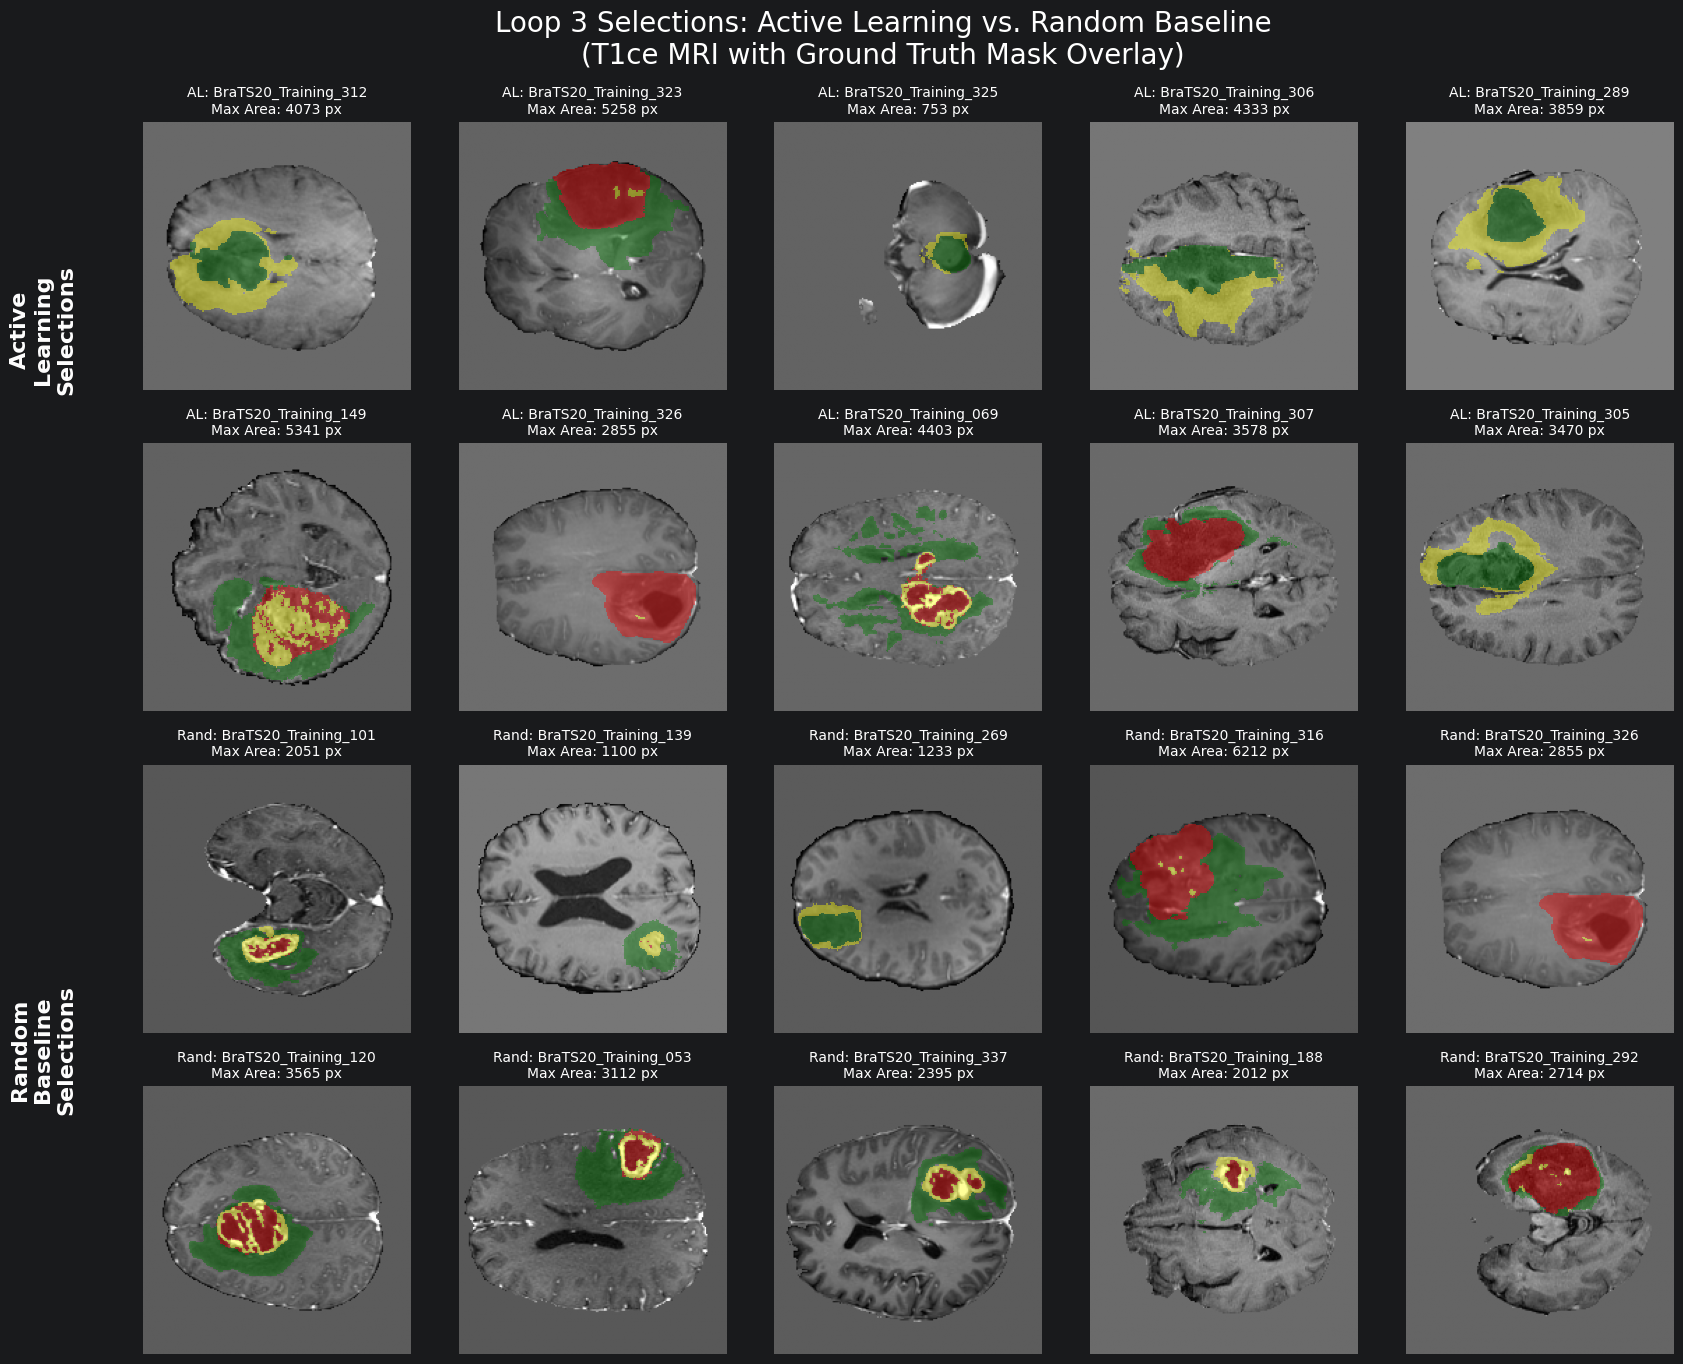

In [45]:
plot_selection_gallery()

In [46]:
# class divergence plot
def plot_class_divergence():
    n_labeled = results_df['n_labeled'].tolist()

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # ED
    axes[0].plot(n_labeled, results_df['al_ed'], 'g-o', linewidth=2.5, markersize=8, label='AL Model')
    axes[0].plot(n_labeled, results_df['random_ed'], 'g--s', linewidth=2.5, markersize=8, alpha=0.6, label='Random Model')
    axes[0].set_title('Edema (ED) Segmentation\nModels tie on large, obvious features', fontsize=14)
    axes[0].set_xlabel('Number of Labeled Patients', fontsize=12)
    axes[0].set_ylabel('Dice Score', fontsize=12)
    axes[0].grid(True, alpha=0.3)
    axes[0].legend(fontsize=12)
    axes[0].set_xticks(n_labeled)

    # NCR
    axes[1].plot(n_labeled, results_df['al_ncr'], 'b-o', linewidth=2.5, markersize=8, label='AL Model')
    axes[1].plot(n_labeled, results_df['random_ncr'], 'r--s', linewidth=2.5, markersize=8, alpha=0.6, label='Random Model')
    axes[1].set_title('Necrotic Core (NCR) Segmentation\nAL breaks away on ambiguous, complex boundaries', fontsize=14)
    axes[1].set_xlabel('Number of Labeled Patients', fontsize=12)
    axes[1].grid(True, alpha=0.3)
    axes[1].legend(fontsize=12)
    axes[1].set_xticks(n_labeled)

    plt.tight_layout()
    plt.show()

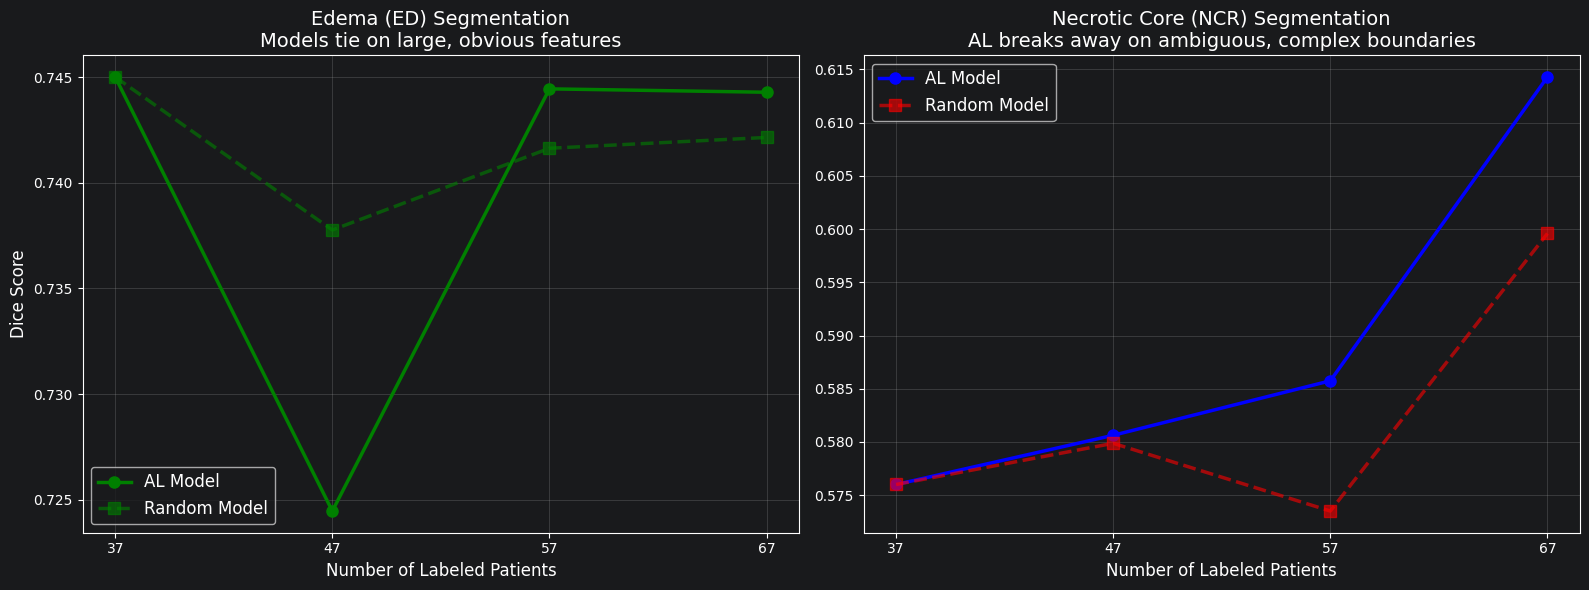

In [47]:
plot_class_divergence()

In [48]:
# we use the same logic as in score_patient_bald()
def compute_bald(mc_probs: torch.Tensor) -> torch.Tensor:
    eps = 1e-8
    mean_probs = mc_probs.mean(dim=0)

    pred_entropy = -(mean_probs * torch.log(mean_probs + eps)).sum(dim=1)
    per_sample_entropy = -(mc_probs * torch.log(mc_probs + eps)).sum(dim=2)
    mean_entropy = per_sample_entropy.mean(dim=0)

    bald_map = (pred_entropy - mean_entropy).clamp(min=0.0)

    return bald_map

In [49]:
def plot_bald_heatmap_for_patient(patient_id, scan_model,
                                  csv_path=CSV_PATH, root_dir=OUTPUT_ROOT,
                                  mc_samples=20, device=DEVICE):

    scan_model.eval()
    scan_model.apply(enable_dropout)

    patient_ds = BraTS25DDataset(
        csv_file=csv_path, root_dir=root_dir,
        patient_ids=[patient_id], transform=val_transform, mode='test'
    )
    patient_loader = DataLoader(patient_ds, batch_size=8, shuffle=False, num_workers=0)

    best_score  = -1
    best_t1ce   = None
    best_mask   = None
    best_bald   = None
    best_slice_idx = None

    df = pd.read_csv(csv_path)
    patient_df = df[df['patient_id'] == patient_id]
    mask_lookup = {
        int(row['slice_idx']): row for _, row in patient_df.iterrows()
    }

    import os
    slice_idx_list = []
    for images, filenames, _ in patient_loader:
        images = images.to(device).float()

        mc_probs_list = []
        with torch.no_grad():
            for _ in range(mc_samples):
                logits = scan_model(images)
                probs  = F.softmax(logits, dim=1)
                mc_probs_list.append(probs.cpu())

        mc_probs = torch.stack(mc_probs_list)       # [T, B, 4, H, W]
        bald_map = compute_bald(mc_probs)           # [B, H, W]
        brain_mask = (images[:, 4:8, :, :].abs() > 1e-6).any(dim=1).cpu()

        for b_idx, fname in enumerate(filenames):
            sl_idx = int(str(fname).split('_slice_')[1].replace('.npy', ''))
            bald_slice = bald_map[b_idx].numpy()     # (192, 192)
            brain      = brain_mask[b_idx].numpy()

            masked_vals = bald_slice[brain]
            if len(masked_vals) == 0:
                continue
            k = max(1, int(len(masked_vals) * 0.05))
            score = float(np.partition(masked_vals, -k)[-k:].mean())

            if score > best_score:
                best_score = score
                best_bald  = bald_slice
                best_slice_idx = sl_idx

                img_path  = os.path.join(root_dir, 'images', str(fname))
                mask_path = os.path.join(root_dir, 'masks',  str(fname))
                row       = mask_lookup.get(sl_idx)
                if row is not None:
                    sy, sx = int(row['crop_start_y']), int(row['crop_start_x'])
                    full_img  = np.load(img_path).astype(np.float32)
                    full_mask = np.load(mask_path).astype(np.uint8)
                    best_t1ce = full_img[sy:sy+192, sx:sx+192, 1]
                    best_mask = full_mask[sy:sy+192, sx:sx+192]

    if best_t1ce is None:
        print(f"Could not find a valid slice for {patient_id}")
        return

    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    fig.patch.set_facecolor('#1a1a2e')
    for ax in axes:
        ax.set_facecolor('#1a1a2e')
        ax.tick_params(left=False, bottom=False,
                       labelleft=False, labelbottom=False)
        for spine in ax.spines.values():
            spine.set_visible(False)

    # T1ce
    axes[0].imshow(best_t1ce, cmap='gray')
    axes[0].set_title(f'T1ce — {patient_id}\nSlice {best_slice_idx}',
                      color='white', fontsize=11)

    # GT mask
    masked = np.ma.masked_where(best_mask == 0, best_mask)
    axes[1].imshow(best_t1ce, cmap='gray')
    axes[1].imshow(masked.astype(float), cmap=cmap_mask,
                   vmin=0, vmax=3, alpha=0.75)
    axes[1].set_title('Ground Truth Mask', color='white', fontsize=11)

    # BALD heatmap
    im = axes[2].imshow(best_bald, cmap='inferno')
    axes[2].set_title(f'BALD Uncertainty Map\n(Top-5% score = {best_score:.5f})',
                      color='white', fontsize=11)
    cbar = plt.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)
    cbar.ax.yaxis.set_tick_params(color='white')
    plt.setp(cbar.ax.yaxis.get_ticklabels(), color='white')

    # BALD overlaid on T1ce
    axes[3].imshow(best_t1ce, cmap='gray')
    axes[3].imshow(best_bald, cmap='inferno', alpha=0.55)
    axes[3].set_title('BALD Overlaid on T1ce', color='white', fontsize=11)

    legend_patches = [mpatches.Patch(color=c, label=l) for c, l in [
        ('#FF4444', 'NCR'), ('#44FF44', 'ED'), ('#FFFF44', 'ET')
    ]]
    fig.legend(handles=legend_patches, loc='lower center', ncol=3,
               fontsize=10, labelcolor='white', facecolor='#2a2a4e',
               edgecolor='gray', bbox_to_anchor=(0.5, 0.0))

    plt.suptitle(f'BALD Uncertainty Explained — {patient_id}',
                 color='white', fontsize=13, fontweight='bold')

    plt.tight_layout(rect=[0, 0.07, 1, 0.95])
    plt.show()

In [50]:
# BALD heatmap on the most uncertain patient from loop 1
baby_model_viz = AgileUNet(n_channels=12, n_classes=4).to(DEVICE)

C:\Users\windo\AppData\Local\Temp\ipykernel_15464\1761242555.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load('artifacts/best_model_initial.pth', map_location=

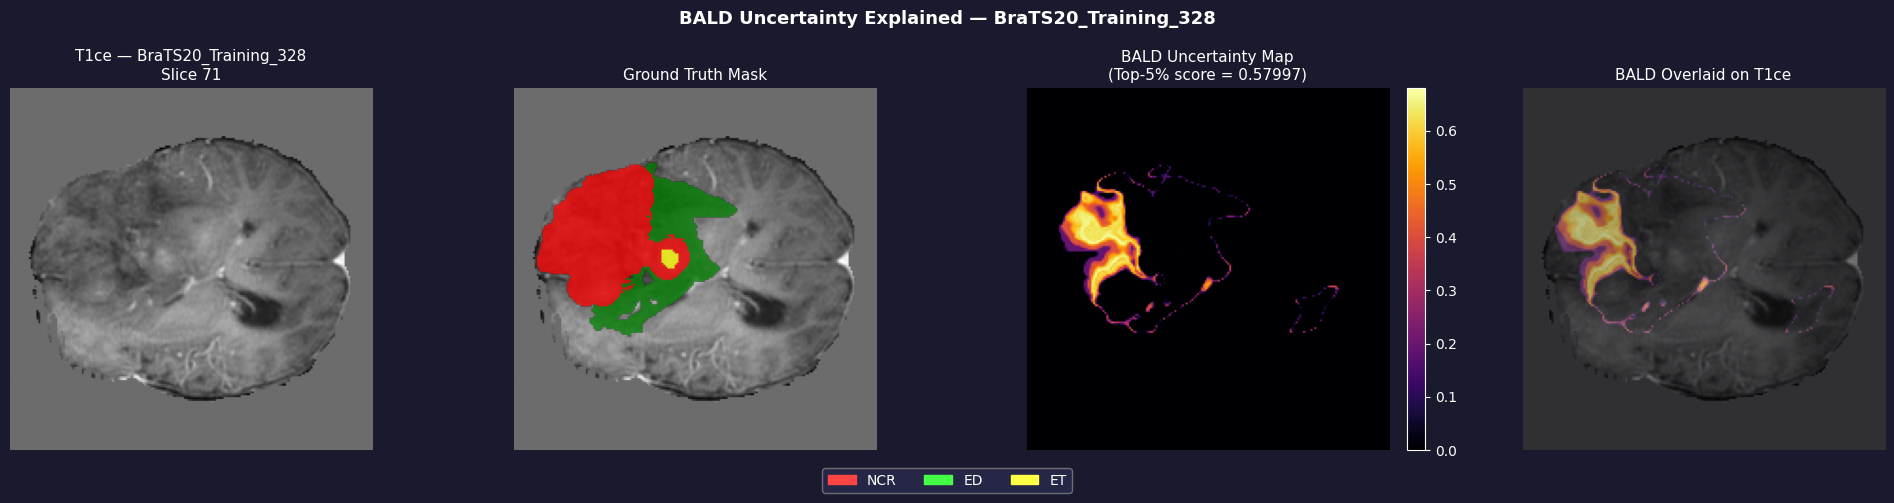

In [51]:
# we use the baby model (that actually scored this patient)
baby_model_viz.load_state_dict(
    torch.load('artifacts/best_model_initial.pth', map_location=DEVICE)
)

loop1_scores = pd.read_csv('docs/al_scores_loop_1.csv')
most_uncertain_patient = loop1_scores.iloc[0]['patient_id']
plot_bald_heatmap_for_patient(most_uncertain_patient, baby_model_viz)